# Volatility Arbitrage Strategy Backtest
This notebook runs a historical backtest for the Volatility Arbitrage (Gamma Scalping) strategy.
It uses Parkinson Volatility for RV and a proxy for IV to simulate the Variance Risk Premium.

In [9]:
import sys
import os
from pathlib import Path
import pandas as pd
import logging

# Add project root to path
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_handler import DataHandler
from src.strategies.volatility_arb import VolatilityArbitrageStrategy
from src.options.data_handler import OptionDataHandler
from src.options.multileg import MultiLegExecutionHelper

# Setup Logging to print to stdout
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

In [10]:
import importlib
import src.strategies.volatility_arb
importlib.reload(src.strategies.volatility_arb)
from src.strategies.volatility_arb import VolatilityArbitrageStrategy

In [11]:
class NoOpExecutionHandler:
    def submit_order(self, symbol, side, qty):
        print(f"[MockExec] {side.upper()} {qty} {symbol}")
    def get_all_positions(self):
        return []
    def close_position(self, symbol):
        print(f"[MockExec] Closing {symbol}")

class NoOpPortfolioManager:
    def check_allocation(self, strategy_id):
        return True

In [12]:
# Configuration
SYMBOL = 'SPY'
START_DATE = '2021-01-01'
END_DATE = '2024-01-01'
INITIAL_CAPITAL = 10000.0

# Initialize Handlers
data_handler = DataHandler(paper_trading=True)
execution_handler = NoOpExecutionHandler()
portfolio_manager = NoOpPortfolioManager()
option_data_handler = OptionDataHandler(data_handler)
multi_leg_helper = MultiLegExecutionHelper(execution_handler)

# Initialize Strategy
strategy = VolatilityArbitrageStrategy(
    data_handler=data_handler,
    execution_handler=execution_handler,
    portfolio_manager=portfolio_manager,
    strategy_id=f"VolArb_{SYMBOL}",
    symbol=SYMBOL,
    option_data_handler=option_data_handler,
    multi_leg_execution=multi_leg_helper,
    lookback_days=30,
    entry_threshold=1.25,
    delta_threshold=25.0,
    stop_loss_iv_mult=1.3,
    contracts=1,
    initial_capital=INITIAL_CAPITAL
)

print(f"Strategy {strategy.strategy_id} initialized.")

# Run Backtest
print("Running backtest...")
results = strategy.run_backtest(START_DATE, END_DATE, initial_capital=INITIAL_CAPITAL)

2025-12-11 11:16:53,760 - src.strategies.base_strategy - INFO - Strategy VolArb_SPY initialized with symbols: ['SPY']
2025-12-11 11:16:53,768 - src.strategies.volatility_arb - INFO - [VolArb_SPY] Starting Backtest from 2021-01-01 to 2024-01-01...
2025-12-11 11:16:53,769 - src.data_handler - INFO - [API] Fetching historical 1D bars for 1 symbols (SPY...)
2025-12-11 11:16:53,768 - src.strategies.volatility_arb - INFO - [VolArb_SPY] Starting Backtest from 2021-01-01 to 2024-01-01...
2025-12-11 11:16:53,769 - src.data_handler - INFO - [API] Fetching historical 1D bars for 1 symbols (SPY...)


Data Handler (alpaca-py) initialized.
Strategy VolArb_SPY initialized.
Running backtest...
Submitting data request to Alpaca...


2025-12-11 11:16:55,226 - src.strategies.volatility_arb - INFO - [VolArb_SPY] Backtest Complete. Total PnL: $2230.25 (22.30%)


Backtest Results for SPY:
Initial Capital: $10000.00
Total PnL: $2230.25
Return: 22.30%
Trades: 5


Total PnL: $2230.25
Return: 22.30%


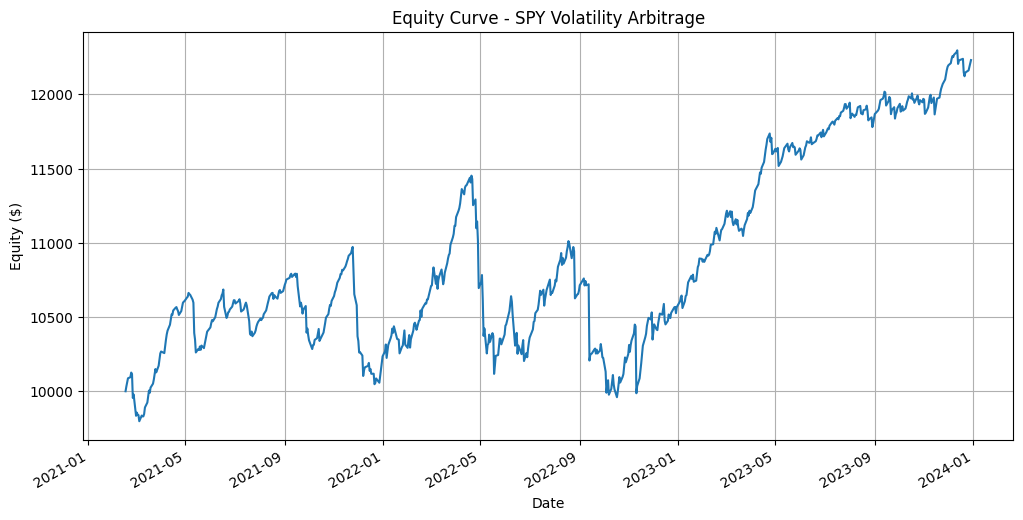


Trade History:


,date,type,price,iv,rv,pnl
0,2021-02-16 05:00:00+00:00,ENTRY,392.38,0.161789,0.124453,NaN
1,2021-03-09 05:00:00+00:00,EXIT_STOP_IV,387.13,NaN,NaN,-169.234915
2,2021-03-10 05:00:00+00:00,ENTRY,389.39,0.211484,0.162680,NaN
3,2022-02-24 05:00:00+00:00,EXIT_STOP_IV,427.99,NaN,NaN,618.255592
4,2022-02-25 05:00:00+00:00,ENTRY,437.75,0.291811,0.224470,NaN


In [13]:
import matplotlib.pyplot as plt
import pandas as pd

if results:
    print(f"Total PnL: ${results['total_pnl']:.2f}")
    print(f"Return: {results['return_pct']:.2f}%")
    
    # Plot Equity Curve
    if not results['equity_curve'].empty:
        plt.figure(figsize=(12, 6))
        results['equity_curve']['equity'].plot()
        plt.title(f"Equity Curve - {SYMBOL} Volatility Arbitrage")
        plt.xlabel("Date")
        plt.ylabel("Equity ($)")
        plt.grid(True)
        plt.show()
    
    # Display Trades
    if not results['trades'].empty:
        print("\nTrade History:")
        display(results['trades'])
    else:
        print("\nNo trades were executed.")
else:
    print("Backtest failed or returned no results.")